# Combine Subduction Results for all runs

This notebook combines results from multiple FESOM particle release runs and visualizes subduction / recirculation pathways around the Arctic.

- Loads raw drifter track data, subduction event CSVs, and gate crossing metadata.
- Combines subduction files into a single dataframe and annotates each event with release day, track type, and season.
- Filters for subducting particles and recirculating pathways (`north`, `south`, `yermak`).
- Builds seasonal grouping of particles by pathway.
- Loads bathymetry and FESOM sea-ice data for map plotting.
- Defines functions for wedge-style map subplots, RGB-style hexbin heatmaps, and a CMY legend.
- Creates figures:
    - Seasonal ensemble RGB heatmaps showing pathway densities.
    - Example individual tracks for each pathway.
    - Additional diagnostic maps of selected drifters and gates.

In [32]:
# General
import numpy as np
import sys
import random

# Data Handling
import xarray as xr
import pandas as pd
#import cftime
import pickle
from collections import Counter

# Plotting
import matplotlib.pyplot as plt
#import matplotlib.path as mpath
#import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
#from matplotlib.lines import Line2D
from matplotlib.collections import PolyCollection
from matplotlib.cm import ScalarMappable
import cmocean as cmo

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry import LineString

# Custom
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
from custom_classes import GateResult, GatesSummary
import particles_loading as pload
import plotting_functions as plf
import helper as hlp

# FESOM
import pyfesom as pf
sys.path.append("/albedo/home/quraus001/FESOM-FS-subduction/functions/")
import FESOM_processing as fprc
#import FESOM_plotting as fplt
import wedge_map as wm

# Paths
inpath_raw = "/albedo/work/user/quraus001/FESOM_particles/result/"
inpath     = "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/"
plotpath   = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/paper/"

font_bold_cond = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLDCOND.OTF' 
font_cond  = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-COND.OTF' 
font_bold  = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLD.OTF' 
font       = "/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-REGULAR.OTF"

## Load Data

In [2]:
files_raw = ["drifter_output_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.nc",
             "drifter_output_2006-091_lat-76_particles-2640_tracking-730d_2026-05-20.nc",
             "drifter_output_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.nc",
             "drifter_output_2006-274_lat-76_particles-2640_tracking-730d_2026-05-20.nc",]

files_sub = ["Subduction-idxs_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.csv",
             "Subduction-idxs_2006-091_lat-76_particles-2640_tracking-730d_2026-05-20.csv",
             "Subduction-idxs_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.csv",
             "Subduction-idxs_2006-274_lat-76_particles-2640_tracking-730d_2026-05-20.csv",]

files_gate = ["Gates_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",
             "Gates_2006-091_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",
             "Gates_2006-182_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",
             "Gates_2006-274_lat-76_particles-2640_tracking-730d_2026-05-20.pkl",]

In [3]:
# Load Gate information (which particle crossed which gates in which order)
gate_data = []
for gate_file in files_gate:
    with open(inpath + gate_file, "rb") as f:
        exp = pickle.load(f)
    gate_data.append(exp)

# Load the complete particle tracks
LAT = 76
DS = {}
for filename in files_raw:
    ds, STEPS_PER_DAY, DOY, YEAR, release_date = pload.read_particle_data(inpath_raw + filename)
    DS[DOY] = ds
    print()

Release date: 2006-01-01 00:00:00
 - Day of year: 1
 - Out steps per day: 12

Release date: 2006-04-01 00:00:00
 - Day of year: 91
 - Out steps per day: 12

Release date: 2006-07-01 00:00:00
 - Day of year: 182
 - Out steps per day: 12

Release date: 2006-10-01 00:00:00
 - Day of year: 274
 - Out steps per day: 12



In [4]:
# Combine all subduction files into one big data frame
# and add some extras

dfs = []
for file_num, filename in enumerate(files_sub, start=1):
    path = inpath + filename
    
    # Read header to extract metadata
    doy = "unknown"
    n_drifters = None
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):
                break
            if "Release DOY" in line:
                doy = int(line.split(":")[-1].strip())
            if "Total processed" in line:
                n_drifters = int(line.split(":")[-1].strip().split()[0])

    # Load the date
    df = pd.read_csv(path, comment="#")

    # Convert stings back to datetimes
    for col in df.columns:
        if col.startswith("datetime"):
            df[col] = pd.to_datetime(df[col])

    # Add release DOY column
    df["release_doy"] = doy


    # Rename drifter index — offset by file_num * 10^(magnitude of n_drifters)
    if n_drifters is not None:
        magnitude = 10 ** (len(str(n_drifters)) + 1)
        df["drifter_id"] = (df["drifter_idx"] + 1).astype(int) # create a new column for drifter_id that is the same as drifter_idx
        df["drifter_idx"] = file_num * magnitude + df["drifter_idx"]

        # Add Track info
        mapping = gate_data[file_num-1].drifter_to_track

        # Convert the column to standard python ints and map
        # .loc ensures we update the dataframe correctly without warnings
        df.loc[:, 'track'] = (
            df['drifter_id']
            .astype(int)              # Ensures numpy.int64 -> python int
            .map(mapping)             # Map to gate names
            .fillna('no track')       # Assign 'no track' if ID isn't in any GateResult
        )

    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Combined {len(files_sub)} files: {len(df_all)} total subduction events")


Combined 4 files: 6111 total subduction events


In [5]:
# Filter only particles that are recirculating and/or subducting
df_sub    = df_all[df_all["category"] == "subduction"].copy()
df_recirc = df_all[df_all["track"].isin(["south", "north", "yermak"])].copy()
df_recirc_sub = df_recirc[df_recirc["category"] == "subduction"].copy()

df_recirc_sub

,drifter_idx,category,warning,time,time_drop,time_start,time_stop,datetime,datetime_drop,datetime_start,...,strain_max_descent,strain_90_descent,okubo_weiss_mean_descent,okubo_weiss_max_descent,depth_mean_descent,depth_min_descent,depth_max_descent,release_doy,drifter_id,track
0,100000,subduction,NaN,1246,691.0,443.0,881.0,2006-04-14 20:00:00,2006-02-27 14:00:00,2006-02-06 22:00:00,...,0.000086,0.000050,-1.160209e-10,-1.508966e-08,33.378687,8.330274,94.237422,1,1,north
1,100001,subduction,NaN,1056,1077.0,919.0,1374.0,2006-03-30 00:00:00,2006-03-31 18:00:00,2006-03-18 14:00:00,...,0.000035,0.000029,-5.867438e-11,-1.440195e-09,97.127703,63.506861,145.246189,1,2,north
2,100002,subduction,resurface warning,3583,1137.0,235.0,1262.0,2006-10-26 14:00:00,2006-04-05 18:00:00,2006-01-20 14:00:00,...,0.000073,0.000028,4.678407e-12,-1.789723e-09,78.456073,9.728631,162.058792,1,3,south
3,100003,subduction,NaN,1051,738.0,360.0,1241.0,2006-03-29 14:00:00,2006-03-03 12:00:00,2006-01-31 00:00:00,...,0.000091,0.000059,2.692550e-10,-4.917324e-09,35.857127,7.716625,143.825198,1,4,south
4,100005,subduction,NaN,3049,3139.0,907.0,3535.0,2006-09-12 02:00:00,2006-09-19 14:00:00,2006-03-17 14:00:00,...,0.000049,0.000025,-6.226985e-11,-1.427224e-09,128.157348,44.300619,196.174917,1,6,south
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6005,401671,subduction,NaN,1269,1185.0,1077.0,1276.0,2007-01-14 18:00:00,2007-01-07 18:00:00,2006-12-29 18:00:00,...,0.000060,0.000046,-1.725250e-10,-3.534413e-09,30.265196,12.146988,68.144328,274,1672,yermak
6024,401703,subduction,NaN,4473,4362.0,3921.0,4510.0,2007-10-08 18:00:00,2007-09-29 12:00:00,2007-08-23 18:00:00,...,0.000016,0.000014,2.587308e-11,1.866603e-10,296.865766,270.201196,320.076577,274,1704,south
6029,401717,subduction,NaN,1610,1837.0,1661.0,2062.0,2007-02-12 04:00:00,2007-03-03 02:00:00,2007-02-16 10:00:00,...,0.000028,0.000025,1.534294e-10,6.375704e-10,149.559834,110.200952,177.477412,274,1718,south
6070,401801,subduction,NaN,1115,1481.0,1259.0,1579.0,2007-01-01 22:00:00,2007-02-01 10:00:00,2007-01-13 22:00:00,...,0.000047,0.000019,5.920123e-11,1.105586e-09,60.500496,34.117326,78.700492,274,1802,north


## Define Tracks and Seasons

In [7]:
for df in [df_sub, df_recirc_sub]:

    # Seasons
    def assign_season(month):
        if month in [12, 1, 2]:
            return "Winter"
        elif month in [3, 4, 5]:
            return "Spring"
        elif month in [6, 7, 8]:
            return "Summer"
        else:
            return "Autumn"
        
    df["season_drop"]  = df["datetime_drop"].dt.month.apply(assign_season)
    df["season_start"] = df["datetime_start"].dt.month.apply(assign_season)
    df["season_sub"]   = df["datetime"].dt.month.apply(assign_season)

sort_by_season = "season_drop"
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
track_map = {
    'north': 'north',
    'south': 'south',
    'yermak': 'yermak',
}

# Build combined structure: {season: {track: [(drifter_id, doy), ...]}}
COMBINED = {season: {track: [] for track in track_map.values()} for season in season_order}

for doy, _ in DS.items():
    df_doy = df_sub[df_sub["release_doy"] == doy].copy() # get all subducting particles that where released on the same day
    if len(df_doy) == 0:
        print(f"DOY {doy}: no subducting particles, skipping")
        continue

    for _, row in df_doy.iterrows(): # loop trough all particles
        season = row[sort_by_season]
        track  = row['track']

        if season not in season_order:
            continue
        if track not in track_map:
            continue  # skip 'no track', 'Svalbard Track' etc.

        COMBINED[season][track_map[track]].append((row['drifter_id'], doy)) # Sort the particle into the right season & track

# Print summary 
for season in season_order:
    for track, pairs in COMBINED[season].items():
        print(f"Season {season:>6} | Track {track:>6}: {len(pairs)} drifters")

print(COMBINED['Winter']['north'][:5])  # Example: first 5 drifter_id, doy pairs for Winter North Recirculation 

Season Winter | Track  north: 218 drifters
Season Winter | Track  south: 300 drifters
Season Winter | Track yermak: 83 drifters
Season Spring | Track  north: 218 drifters
Season Spring | Track  south: 375 drifters
Season Spring | Track yermak: 110 drifters
Season Summer | Track  north: 83 drifters
Season Summer | Track  south: 161 drifters
Season Summer | Track yermak: 88 drifters
Season Autumn | Track  north: 105 drifters
Season Autumn | Track  south: 313 drifters
Season Autumn | Track yermak: 53 drifters
[(1, 1), (11, 1), (71, 1), (82, 1), (119, 1)]


In [ ]:
# Print some percentages
for track in ["north", "south", "yermak"]:
    print(track, len(df_recirc_sub[df_recirc_sub["track"]==track]) / len(df_recirc_sub) *100, len(df_recirc_sub[df_recirc_sub["track"]==track]))

for season in season_order:
    count = 0
    for track in ["north", "south", "yermak"]:
        count += len(COMBINED[season][track])

    print(season, count/len(df_recirc_sub) *100, count)

    for track in ["north", "south", "yermak"]:
        print("   ", track, len(COMBINED[season][track])/count *100, len(COMBINED[season][track]))

north 29.615567157095395 624
south 54.53251067869008 1149
yermak 15.851922164214525 334
Winter 28.523967726625532 601
    north 36.272878535773714 218
    south 49.91680532445923 300
    yermak 13.810316139767053 83
Spring 33.36497389653536 703
    north 31.0099573257468 218
    south 53.34281650071123 375
    yermak 15.647226173541965 110
Summer 15.757000474608448 332
    north 25.0 83
    south 48.493975903614455 161
    yermak 26.506024096385545 88
Autumn 22.354057902230657 471
    north 22.29299363057325 105
    south 66.45435244161358 313
    yermak 11.252653927813164 53


## Map

In [18]:
# Load bathymetry data
ds_bath = xr.open_dataset("/albedo/work/user/quraus001/bath/ETOPO_2022_v1_60s_N90W180_bed.nc")
# select only reagion of interest
ds_bath = ds_bath.sel(lon=slice(-40, 40), lat=slice(70, 90))


# Load FESOM sea ice data

#from cdo import Cdo
#cdo = Cdo()
#file =  "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.ice.mean.sub.nc"
# make seasonal means
#cdo.seasmean(input=file, output="/albedo/work/user/quraus001/FESOM_particles/result/processed_results/Arc40.2006.ice.mean.seasonal.sub.nc")

mesh = pf.load_mesh("/albedo/home/quraus001/Arc08_sub/")
ds_ice_seasonal = fprc.load_FESOM_data_with_grid("/albedo/home/quraus001/Arc08_sub/", "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/Arc40.2006.ice.mean.seasonal.sub.nc")

/albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
3
The usepickle == True)
The pickle file for python 3 exists.
The mesh will be loaded from /albedo/home/quraus001/Arc08_sub/pickle_mesh_py3


In [19]:
def build_wedge_subplots(fig, nrows=2, ncols=2, extent=[-25, 25, 75, 83], projection=ccrs.NorthPolarStereo()):
    axs = []

    for i in range(1, nrows*ncols + 1):
        pos = 100 * nrows + 10 * ncols + i
        _, ax = plf.plot_empty_map_wedge(extent=extent, land_color=None, land_zorder=50, fig=fig, ax=None, position=pos, figsize=(15, 4), projection=projection)
        axs.append(ax)

    #print(f"Built {len(axs)} wedge subplots with positions {[100 * nrows + 10 * ncols + i for i in range(1, nrows*ncols + 1)]}")

    axs = np.array(axs).reshape(nrows, ncols)
    #print(f"Reshaped axs to {axs.shape} for nrows={nrows}, ncols={ncols}")
    return axs

In [20]:
# Define the Bins for the Heat Map
# 1. Define the map limits (in degrees)
lon_lims = [-25, 25]
lat_lims = [75, 83]

# 2. Create a dense boundary of the map to find the true min/max in meters
# This samples points along all four edges of your wedge
lons_edge = np.concatenate([
    np.linspace(lon_lims[0], lon_lims[1], 50), # Bottom edge
    np.full(50, lon_lims[1]),                  # Right edge
    np.linspace(lon_lims[1], lon_lims[0], 50), # Top edge
    np.full(50, lon_lims[0])                   # Left edge
])
lats_edge = np.concatenate([
    np.full(50, lat_lims[0]),                  # Bottom edge
    np.linspace(lat_lims[0], lat_lims[1], 50), # Right edge
    np.full(50, lat_lims[1]),                  # Top edge
    np.linspace(lat_lims[1], lat_lims[0], 50)  # Left edge
])

equal_area_crs = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)
# Project this boundary to find the true physical limits
boundary_projected = equal_area_crs.transform_points(ccrs.PlateCarree(), lons_edge, lats_edge)
X_MIN, X_MAX = boundary_projected[:, 0].min(), boundary_projected[:, 0].max()
Y_MIN, Y_MAX = boundary_projected[:, 1].min(), boundary_projected[:, 1].max()

# 3. Calculate Global Gridsize for EXACTLY 25km
# Gridsize is the number of hexagons across the X-range
X_RANGE_M = X_MAX - X_MIN
GLOBAL_GRIDSIZE = int(X_RANGE_M / 25000)
GLOBAL_EXTENT = [X_MIN, X_MAX, Y_MIN, Y_MAX]

print(f"Calculated Master Gridsize: {GLOBAL_GRIDSIZE}")


Calculated Master Gridsize: 56


In [21]:
VMAX = 100
N_STEPS = 10
COLORS = [(0, 1, 1), (1, 0, 1), (1, 1, 0)]  # CMY

LABELS = ['North', 'South', 'Yermak']

# Simple
def make_cmaps(colors_rgb, n_steps):
    cmaps = []
    for color in colors_rgb:
        cmap_full = mcolors.LinearSegmentedColormap.from_list('', [(1,1,1), color], N=n_steps + 1)
        colors_list = cmap_full(np.linspace(0, 1, n_steps + 1))[1:]
        cmaps.append(mcolors.ListedColormap(colors_list))
    return cmaps

# Hand-tuned for perceptual clarity and monitor limitations
def make_cmaps(colors_rgb, n_steps):
    cmaps = []
    
    # --- THE BESPOKE PERCEPTUAL ARRAY ---
    # We hand-craft the 10 steps to give your eyes exactly what they need:
    # - Small, gentle steps at the bottom (0 to 30) so they don't jump too fast.
    # - Massive, accelerating mathematical leaps at the top (60 to 100) to force
    #   your monitor to actually change shades before hitting a max cap of 0.82.
    if n_steps == 10:
        custom_space = np.array([0, 0.1, 0.20, 0.28, 0.36, 0.44, 0.52, 0.60, 0.75, 1])
    else:
        # Fallback for 4 steps if needed
        custom_space = np.linspace(0.15, 0.85, n_steps)
        
    for color in colors_rgb:
        cmap_full = mcolors.LinearSegmentedColormap.from_list('', [(1,1,1), color], N=256)
        
        # Sample using our hand-crafted, non-clipping checkpoints
        colors_list = cmap_full(custom_space)
        cmaps.append(mcolors.ListedColormap(colors_list))
        
    return cmaps

# Instantiate cleanly
CMAPS = make_cmaps(COLORS, N_STEPS)

In [22]:
def add_rgb_colorbars(fig, axs, cmaps, labels, vmax=VMAX, n_steps=N_STEPS, orientation='vertical', pad=0.02, fraction=0.02):
    cbars = []
    boundaries = np.linspace(0, vmax, n_steps + 1)
    for i, (cmap, label) in enumerate(zip(cmaps, labels)):
        norm = mcolors.BoundaryNorm(boundaries, ncolors=n_steps)
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        cb = fig.colorbar(sm, ax=axs, extend='max',
            orientation=orientation, pad=pad, fraction=fraction,
            ticks=boundaries,  # tick at each boundary 
        )

        if i > 0:  # Only set ticklabels for the first two colorbars
            cb.set_ticklabels([])

        if orientation == 'vertical':
            rotation = 90
            va, ha = 'center', 'center'
        else:
            rotation = 0
            va, ha = 'center', 'center'
        cb.set_label('')
        cb.ax.text(
            0.5, 0.5, label,
            transform=cb.ax.transAxes,
            rotation=rotation,
            va=va, ha=ha,
            fontsize=8,
            color='black',
        )
        cbars.append(cb)
    return cbars

In [23]:
def plot_rgb_heatmap(drifter_id_sets_with_ds, cmaps, ax, vmax=VMAX, n_steps=N_STEPS):
    all_counts = []

    # --- Collect all points across all tracks for the reference hexbin ---
    all_lons, all_lats, all_ids = [], [], []
    per_track_points = []

    for pairs in drifter_id_sets_with_ds:
        lons, lats, ids = [], [], []
        for d_id, ds in pairs:                               # <-- unpack tuple
            d_data = ds.sel(drifter=d_id)                   # <-- use the right ds
            mask = np.isfinite(d_data.lon.values) & np.isfinite(d_data.lat.values)
            lons.extend(d_data.lon.values[mask])
            lats.extend(d_data.lat.values[mask])
            ids.extend([d_id] * np.sum(mask))
        per_track_points.append((lons, lats, ids))
        all_lons.extend(lons)
        all_lats.extend(lats)

    # Project all points
    def project(lons, lats):
        p = equal_area_crs.transform_points(ccrs.PlateCarree(), np.array(lons), np.array(lats))
        return p[:, 0], p[:, 1]

    # --- Use a single reference hexbin to define the grid ---
    # Use ALL points so every possible hex cell is initialized
    x_all, y_all = project(all_lons, all_lats)

    fig_tmp, ax_tmp = plt.subplots()
    hb_ref = ax_tmp.hexbin(
        x_all, y_all,
        gridsize=GLOBAL_GRIDSIZE,
        extent=GLOBAL_EXTENT,
        mincnt=0,
    )
    offsets = np.array(hb_ref.get_offsets())   # (n_hex, 2) — the true hex centers
    ref_path = hb_ref.get_paths()[0]            # the unit hexagon path (already scaled!)
    ref_verts = ref_path.vertices               # shape (7, 2) — actual size in data coords
    plt.close(fig_tmp)

    n_hex = len(offsets)

    # --- Now get per-track counts on the same grid ---
    fig_tmp, ax_tmp = plt.subplots()
    for lons, lats, ids in per_track_points:
        x, y = project(lons, lats)
        hb = ax_tmp.hexbin(
            x, y,
            C=np.array(ids),
            reduce_C_function=lambda val: len(set(val)),
            gridsize=GLOBAL_GRIDSIZE,
            extent=GLOBAL_EXTENT,
            mincnt=0,
        )
        all_counts.append(hb.get_array().copy())
    plt.close(fig_tmp)

    all_counts = np.array(all_counts)  # (3, n_hex)

    # --- Normalize and blend ---
    all_counts_norm = np.clip(all_counts / vmax, 0, 1)
    rgb = np.ones((n_hex, 3))

    # Pre-calculate the step indices for all hexagons at once (values 0 to n_steps-1)
    # This maps the continuous data into your 4 discrete colorbar bins
    step_indices = np.minimum(np.floor(all_counts_norm * n_steps).astype(int), n_steps - 1) ################# NEW

    if False:  # Original linear blending (for reference)
        for i, cmap in enumerate(cmaps):
            weight = all_counts_norm[i][:, np.newaxis]
            # Sample the cmap to get the blending color at this weight
            sampled = np.array([cmap(w)[:3] for w in all_counts_norm[i]]) 
            # Subtractive blend using the cmap color
            rgb -= (1 - sampled) * weight  # or just use sampled directly


    step_indices = np.minimum(np.floor(all_counts_norm * n_steps).astype(int), n_steps - 1)

    for i, cmap in enumerate(cmaps):
        cmap_colors = np.array(cmap.colors)[:, :3] # Keep RGB, drop Alpha
        sampled_colors = cmap_colors[step_indices[i]] 
        
        # --- THE FIX ---
        # Instead of multiplying by a secondary linear weight, we directly subtract
        # the white inversion of our gamma-corrected colors wherever counts exist.
        mask = all_counts[i] > 0
        rgb[mask] -= (1 - sampled_colors[mask])

    rgb = np.clip(rgb, 0, 1)

    # Keep this from your original code to filter out empty hexagons
    any_count = all_counts.sum(axis=0) > 0
    

    # --- Build vertices: ref_verts are already in data coords (meters), just shift by center ---
    verts = []
    face_colors = []
    for i, (cx, cy) in enumerate(offsets):
        if not any_count[i]:
            continue
        # ref_verts is centered at (0,0), shift to actual hex center
        verts.append(ref_verts[:-1] + np.array([cx, cy]))  # drop repeated closing vertex
        face_colors.append(rgb[i])

    col = PolyCollection(
        verts,
        facecolors=face_colors,
        edgecolors='none',
        transform=equal_area_crs,
        zorder=0,
    )
    ax.add_collection(col)
    return col

In [24]:
# Gates
P1 = LineString([(3, 79.1), (10, 79.1)] )
P2 = LineString([(-2, 75), (0.5, 79), (-2, 80.2), (-12, 81)] )
P3 = LineString([(14, 79.8), (8, 81.2), (13, 81.5)] )
P4 = LineString([(-2, 81), (4, 81)] )
P5 = LineString([(16.7, 76.6), (18.9, 74.45)] )

Label_locs = [(10,78), (-10,79.5), (12,81.5), (-2,81.1)]


def gates_on_map(ax, labels = True, points = False):

    gates       = [P1, P2, P3, P4]#, P5]
    gate_colors = ["black", "blue", "red", "green", "mediumturquoise"]
    gate_names  = ["P1", "P2", "P3", "P4", "P5"]
    # Bathymetry

    for line, color, name, label_loc in zip(gates, gate_colors, gate_names, Label_locs):
        # Plotting
        x, y = line.xy
        ax.plot(x, y, color=color, linewidth=2, label='Boundary Line',
            transform=ccrs.PlateCarree(), zorder=12)
        if points:
            ax.scatter(x, y, color='black', zorder=13,
                transform=ccrs.PlateCarree()) # Endpoints
        mid = len(x) // 2
        
        if labels:
            ax.text(label_loc[0], label_loc[1], name, color=color,
                transform=ccrs.PlateCarree(), fontsize=12, fontweight="bold", zorder=14,
                ha='left', va='bottom',)
                #bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))  # white background for readability

    return ax

In [25]:
def cmy_to_rgb(weights):
    """
    weights: (..., 3) array in C, M, Y order.
    Returns RGB colors.
    Rule:
      - pure C  -> cyan
      - pure M  -> magenta
      - pure Y  -> yellow
      - equal C/M/Y -> black
    """
    w = np.clip(np.asarray(weights, dtype=float), 0.0, 1.0)

    # Normalize per point so the strongest channel becomes 1.
    # This is what makes the center of the triangle go to black.
    mx = np.max(w, axis=-1, keepdims=True)
    mx = np.where(mx == 0, 1.0, mx)
    ink = w / mx

    # CMY -> RGB
    rgb = 1.0 - ink
    return np.clip(rgb, 0.0, 1.0)

In [26]:
def add_cmy_triangle_legend(fig, cmaps, loc=(0.02, 0.02), size=0.22, resolution=400):
    corners = np.array([
        [0.5, np.sqrt(3)/2],   # C top
        [1.0, 0.0],            # M bottom-right
        [0.0, 0.0],            # Y bottom-left
    ], dtype=float)

    ax = fig.add_axes([loc[0], loc[1], size, size * 1.1])
    ax.set_aspect('equal')
    ax.axis('off')

    # --- Smooth fill over a dense grid ---
    x = np.linspace(0.0, 1.0, resolution)
    y = np.linspace(0.0, np.sqrt(3)/2, resolution)
    X, Y = np.meshgrid(x, y)

    x1, y1 = corners[0]
    x2, y2 = corners[1]
    x3, y3 = corners[2]

    den = (y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3)

    wC = ((y2 - y3) * (X - x3) + (x3 - x2) * (Y - y3)) / den
    wM = ((y3 - y1) * (X - x3) + (x1 - x3) * (Y - y3)) / den
    wY = 1.0 - wC - wM

    inside = (wC >= 0) & (wM >= 0) & (wY >= 0)
    weights = np.stack([wC, wM, wY], axis=-1)

    rgb = cmy_to_rgb(weights)
    rgba = np.dstack([rgb, inside.astype(float)])

    ax.imshow(
        rgba,
        origin='lower',
        extent=(0.0, 1.0, 0.0, np.sqrt(3)/2),
        interpolation='bilinear',
        zorder=0
    )

    # Border
    tri = plt.Polygon(corners, fill=False, edgecolor='black', linewidth=1.2, zorder=2)
    ax.add_patch(tri)

    # Pure CMY anchor colors
    c_color = np.array([0.0, 1.0, 1.0])
    m_color = np.array([1.0, 0.0, 1.0])
    y_color = np.array([1.0, 1.0, 0.0])

    # Corner dots and labels
    offsets = [(0.00, 0.06), (0.06, -0.08), (-0.06, -0.08)]
    labels = ['C', 'M', 'Y']
    dot_colors = [c_color, m_color, y_color]

    for (cx, cy), lbl, clr, (dx, dy) in zip(corners, labels, dot_colors, offsets):
        ax.plot(cx, cy, 'o', color=clr, ms=8, zorder=5,
                markeredgecolor='white', markeredgewidth=0.8)
        #ax.text(cx + dx, cy + dy, lbl, ha='center', va='center',
        #        fontsize=7, fontweight='bold', color='black')

    # Midpoints
    midpoints = [
        (corners[0] + corners[1]) / 2,
        (corners[1] + corners[2]) / 2,
        (corners[0] + corners[2]) / 2
    ]
    midpoint_colors = [
        cmy_to_rgb(np.array([1.0, 1.0, 0.0])),  # C+M -> blue
        cmy_to_rgb(np.array([0.0, 1.0, 1.0])),  # M+Y -> green
        cmy_to_rgb(np.array([1.0, 0.0, 1.0])),  # C+Y -> red
    ]

    for mid, clr in zip(midpoints, midpoint_colors):
        ax.plot(*mid, 'o', color=clr, ms=5, zorder=5,
                markeredgecolor='white', markeredgewidth=0.6)

    # Center dot: black
    centroid = corners.mean(axis=0)
    ax.plot(*centroid, 'o', color='black', ms=5, zorder=5,
            markeredgecolor='#888', markeredgewidth=0.6)

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, np.sqrt(3)/2 + 0.15)

    return ax

In [28]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_rgb_colorbars_inset(fig, cmaps, labels, vmax=VMAX, n_steps=N_STEPS, pos=(0.35, 0.51), size=(0.30, 0.08)):
    """
    Creates a clean, uniform vertical stack of 3 horizontal colorbars 
    using absolute figure placement.
    """
    boundaries = np.linspace(0, vmax, n_steps + 1)
    norm = mcolors.BoundaryNorm(boundaries, ncolors=n_steps)
    
    # Initialize the absolute background container
    cax_container = fig.add_axes([pos[0], pos[1], size[0], size[1]])
    cax_container.axis('off')

    # Perfectly divide the container's vertical space (3 bars + 2 gaps)
    # 0.26 * 3 + 0.11 * 2 = 0.78 + 0.22 = 1.0 (fills 100% of container height)
    bar_height = 0.26
    gap = 0.11

    # Reorder label and cmaps to that 0->1, 1->2, 2->0 (dont ask... I just dont want to change everything else)
    labels = [labels[1], labels[0], labels[2]]
    cmaps = [cmaps[1], cmaps[0], cmaps[2]]

    for i, (cmap, label) in enumerate(zip(cmaps, labels)):
        # Calculate vertical positioning (Bottom-up: i=0 is baseline)
        y_pos = i * (bar_height + gap)
        
        # Spawn the clean bar slice
        ax_slice = cax_container.inset_axes([0, y_pos, 1.0, bar_height])
        
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        
        # Render colorbar natively inside the slice
        cb = fig.colorbar(sm, cax=ax_slice, extend='max', orientation='horizontal', ticks=boundaries)
        
        # Handle ticks strictly on the baseline bar (i = 0)
        if i == 0:
            cb.ax.tick_params(axis='x', labelsize=8, direction='out', pad=3, colors='black', labelbottom=True)
            cb.set_ticklabels([f"{b:.0f}" for b in boundaries]) 
        else:
            cb.ax.tick_params(axis='x', bottom=False, labelbottom=False)
            cb.set_ticklabels([])
            
        # Clear default labels and overlay clean centered text strings
        cb.set_label('')
        cb.ax.text(
            0.5, 0.5, label,
            transform=cb.ax.transAxes,
            va='center', ha='center',
            fontsize=8, color='black', weight='bold'
        )


Season: Winter
  north  (total=218):  {1: 57, 91: 10, 182: 57, 274: 94}
  south  (total=300):  {1: 69, 91: 35, 182: 101, 274: 95}
  yermak (total=83): {1: 38, 91: 4, 182: 11, 274: 30}

Season: Spring
  north  (total=218):  {1: 150, 91: 15, 182: 18, 274: 35}
  south  (total=375):  {1: 186, 91: 35, 182: 69, 274: 85}
  yermak (total=110): {1: 78, 91: 19, 182: 6, 274: 7}

Season: Summer
  north  (total=83):  {1: 24, 91: 40, 182: 11, 274: 8}
  south  (total=161):  {1: 46, 91: 57, 182: 34, 274: 24}
  yermak (total=88): {1: 15, 91: 61, 182: 12}

Season: Autumn
  north  (total=105):  {1: 11, 91: 22, 182: 54, 274: 18}
  south  (total=313):  {1: 50, 91: 68, 182: 171, 274: 24}
  yermak (total=53): {1: 3, 91: 8, 182: 29, 274: 13}


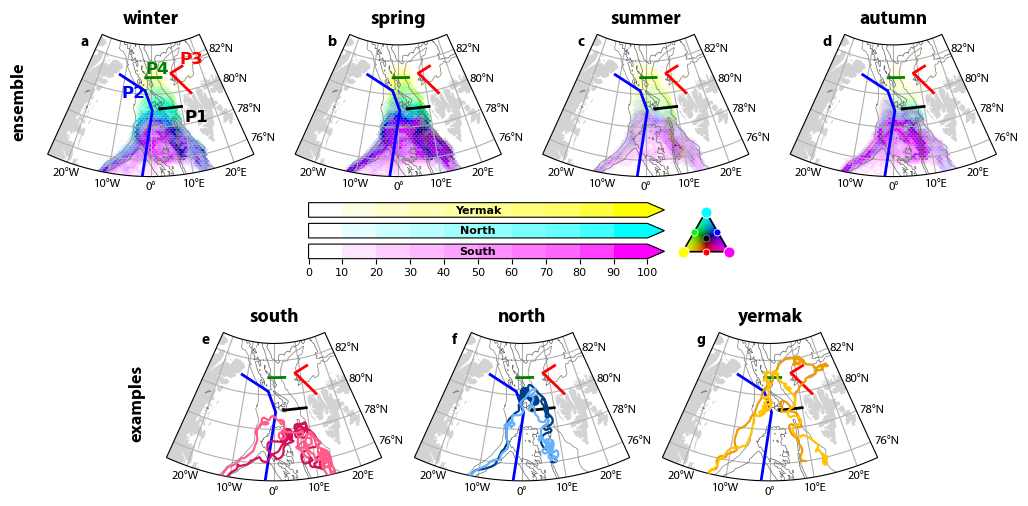

In [34]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]
pathway_order = ["south", "north", "yermak"]

# --- 1. BUILD THE FIGURE WITH A CUSTOM GRIDSPEC LAYOUT ---
fig = plt.figure(figsize=(11.86, 7.0))

# Define the geographic extent and projection for all map axes
lon_min, lon_max = -25, 25
lat_min, lat_max = 75, 83
map_proj = ccrs.AlbersEqualArea(
    central_longitude=(lon_min + lon_max) / 2, central_latitude=(lat_min + lat_max) / 2,
    standard_parallels=(lat_min, lat_max)
)

# Build the gridspec with custom width ratios to create "wings" on the bottom row
wspace = 0.2
row_gap = 0 # Make it bigger if the vertical gap between rows needs to be increased

wing_ratio = 0.5 - (wspace / 2.0)

# Top Row: Standard 4 columns
gs_top = gridspec.GridSpec(
    nrows=1, ncols=4, figure=fig, 
    bottom=0.51 + (row_gap / 2.0), 
    top=0.94, left=0.08, right=0.88, 
    hspace=0.25, wspace=wspace
)

# Bottom Row: 5 columns using your custom width ratios to center the active panels (And make them the same size as the top row)
gs_bot = gridspec.GridSpec(
    nrows=1, ncols=5, figure=fig,
    width_ratios=[wing_ratio, 1.0, 1.0, 1.0, wing_ratio], # Shrinks outer wings, balances the middle 3
    bottom=0.08, top=0.51 - (row_gap / 2.0), 
    left=0.08, right=0.88, 
    hspace=0.25, 
    wspace=wspace
)

# Allocate axis (Skipping columns 0 and 4 on the bottom row) 
# Top row populates all 4 slots natively
axs_heat = [fig.add_subplot(gs_top[0, col], projection=map_proj) for col in range(4)]

# Bottom row populates slots 1, 2, and 3, leaving the 0.5-width columns blank!
axs_ex   = [fig.add_subplot(gs_bot[0, col], projection=map_proj) for col in [1, 2, 3]]

all_axs = axs_heat + axs_ex

# --- 2. ADD BASIC MAP FEATURES & APPLY WEDGE CLIPPING ---

gate_labels = True
# Apply your wedge clipping function to map axes only
for ax in all_axs:
    wm.wedge_map_boudary(
        ax=ax, projection=map_proj, 
        lon_min=lon_min, lon_max=lon_max, 
        lat_min=lat_min, lat_max=lat_max, 
        land_color='lightgrey'
    )

    wm.add_wedge_gridlines(
        ax, latitudes=[76, 78, 80, 82], longitudes=[-20, -10, 0, 10, 20],
        lat_text=26, lon_text_bottom=74.7, zorder=11, fontsize=9, lines=True,
        show_top=False, show_bottom=True, show_left=False, show_right=True, # Right labels OFF
        font_path=font
    )
    
    # Text overlays and bathymetry
    ax.contour(
        ds_bath.lon.values[::8], ds_bath.lat.values[::4], ds_bath.z.values[::4, ::8] * -1, linewidths=0.5,
        levels=[1000, 3000, 5000], colors=["grey", "dimgrey", "black"], transform=ccrs.PlateCarree()
    )

    # Gates that define the pathways (only label on the first one to avoid overcrowding)
    gates_on_map(ax, labels=gate_labels)
    gate_labels = False


# --- 3. ENSEMBLE HEATMAP ROW (Top) ---
for ax, season in zip(axs_heat, season_order):
    if True: # Turn this off when debugging the plot because it takes the longest to run
        north_pairs  = [(d_id, DS[doy]) for d_id, doy in COMBINED[season]['north']]
        south_pairs  = [(d_id, DS[doy]) for d_id, doy in COMBINED[season]['south']]
        yermak_pairs = [(d_id, DS[doy]) for d_id, doy in COMBINED[season]['yermak']]

        north_doys  = Counter(doy for d_id, doy in COMBINED[season]['north'])
        south_doys  = Counter(doy for d_id, doy in COMBINED[season]['south'])
        yermak_doys = Counter(doy for d_id, doy in COMBINED[season]['yermak'])

        print(f"\nSeason: {season}")
        print(f"  north  (total={len(north_pairs)}):  {dict(north_doys)}")
        print(f"  south  (total={len(south_pairs)}):  {dict(south_doys)}")
        print(f"  yermak (total={len(yermak_pairs)}): {dict(yermak_doys)}")


        hb = plot_rgb_heatmap(
            drifter_id_sets_with_ds=[north_pairs, south_pairs, yermak_pairs],
            cmaps=CMAPS,
            ax=ax,
        )   
    prop = fm.FontProperties(fname=font_bold, size=14)
    ax.set_title(f"{season.lower()}", fontproperties=prop, pad=8)

# --- 4. PATHWAY EXAMPLES ROW (Bottom) ---
picked_tracks = {
    "north" : [(644,274), (437, 1), (265, 91)],
    "south" : [(578,1), (1742, 1), (1545, 182)],
    "yermak": [(1323, 274), (792, 182), (1665, 91)]
}

track_colors = {
    "north":  ["#1A85FF", "#003F88", "#66B2FF"],  
    "south":  ["#7209B7", "#D41159", "#FF5C8A"],  
    "yermak": ["#9A5300", "#EE9B00", "#FFC300"]   
}

for ax, path_type in zip(axs_ex, pathway_order):
    for sample in range(1,3): # just choosing two examples
        particle, doy = picked_tracks[path_type][sample]

        d_data = DS[doy].sel(drifter=particle)
        mask = np.isfinite(d_data.lon.values) & np.isfinite(d_data.lat.values)
        ax.plot(
            d_data.lon.values[mask], d_data.lat.values[mask], 
            transform=ccrs.PlateCarree(), zorder=13, linewidth=1.6, color=track_colors[path_type][sample]
        )
    prop = fm.FontProperties(fname=font_bold, size=14)
    ax.set_title(f"{path_type}", fontproperties=prop, pad=8)


# --- 5. FINALIZE FORMATTING ---

add_rgb_colorbars_inset(fig, CMAPS, LABELS, vmax=VMAX, pos=(0.3, 0.5), size=(0.30, 0.08))
add_cmy_triangle_legend(fig, CMAPS, loc=(0.6, 0.5), size=0.07)

# Label the main rows on the left side
axs_heat[0].text(-0.1, 0.5, "ensemble", transform=axs_heat[0].transAxes, 
                 va='center', ha='right', rotation=90, fontproperties=fm.FontProperties(fname=font_bold, size=13))
axs_ex[0].text(-0.1, 0.5, "examples", transform=axs_ex[0].transAxes, 
               va='center', ha='right', rotation=90, fontproperties=fm.FontProperties(fname=font_bold, size=13))

# Label panels sequentially (a-g), completely skipping the colorbar row
subplot_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
for ax, label in zip(all_axs, subplot_labels):
    ax.text(0.2, 1.0, label, transform=ax.transAxes, va='top', ha='right', fontproperties=fm.FontProperties(fname=font_bold, size=11))

plt.savefig(plotpath + "heatmap_with_examples_gridspec.png", dpi=300, bbox_inches="tight", transparent=False)
plt.show()